In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from models import CRW
from tqdm import tqdm

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
figsize = (12,9)

In [3]:
# generate 1000 CRW polymers of length 10-1000, and record their statistics
low=10
high=1000

num_crw = 500

rng = np.random.default_rng()
crw_list = [CRW(int(10**rng.uniform(np.log10(low),np.log10(high)))) for i in tqdm(range(num_crw))]

100%|██████████| 500/500 [00:03<00:00, 125.69it/s]


In [4]:
print(crw_list)
crw_list = sorted(crw_list, key=lambda x: x.n)
print(crw_list)

[<models.CRW object at 0x70dccba917f0>, <models.CRW object at 0x70dccba3c080>, <models.CRW object at 0x70dccb6e3950>, <models.CRW object at 0x70dccb0ec710>, <models.CRW object at 0x70dccc77ad80>, <models.CRW object at 0x70dccb0ec500>, <models.CRW object at 0x70dccb0ec6b0>, <models.CRW object at 0x70dccb11da30>, <models.CRW object at 0x70dccb11da60>, <models.CRW object at 0x70dccb11d970>, <models.CRW object at 0x70dccb11db80>, <models.CRW object at 0x70dccb11da90>, <models.CRW object at 0x70dccb11dd00>, <models.CRW object at 0x70dccb11dd30>, <models.CRW object at 0x70dccb11dd60>, <models.CRW object at 0x70dccb11db20>, <models.CRW object at 0x70dccb11dc70>, <models.CRW object at 0x70dccb11ddc0>, <models.CRW object at 0x70dccb11dbe0>, <models.CRW object at 0x70dccb11ddf0>, <models.CRW object at 0x70dccb11de20>, <models.CRW object at 0x70dccb11dc10>, <models.CRW object at 0x70dccb0ec7d0>, <models.CRW object at 0x70dccb11df10>, <models.CRW object at 0x70dccb11df40>, <models.CRW object at 0x

In [5]:
crw_list[0].show()
crw_list[1].show()

CRW of length 10:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 1.9973787069320679
	Total Potential Energy: 4.263256414560601e-14
Residues:
(-2.706568956375122, 1.4903028011322021, 0.7033799886703491)
(-2.1076321601867676, 0.9201030135154724, 1.2656493186950684)
(-1.6430532932281494, 0.5451865196228027, 0.4633999466896057)
(-0.8256534337997437, 0.09196007251739502, 0.10781127214431763)
(0.1419830322265625, 0.26046574115753174, -0.08003252744674683)
(0.21362686157226562, -0.03660380840301514, -1.0321967601776123)
(1.1513686180114746, -0.24518871307373047, -0.7544686794281006)
(1.385211706161499, -0.506499171257019, 0.18203234672546387)
(1.6962096691131592, -1.2311556339263916, -0.43290936946868896)
(2.694507360458374, -1.2885711193084717, -0.4226663112640381)
CRW of length 10:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 1.3507311344146729
	Total Potential Energy: 1.7763568394002505e-14
Residues:
(-1.2259210348129272, 1.2025320529937744, 0.7621391415596008)
(-0.85

In [6]:
def Rg_func(N, v):
    return N**v

In [7]:
lengths = [crw.n for crw in tqdm(crw_list)]
R_gs = [float(crw.compute_rg()) for crw in tqdm(crw_list)]
xdata = lengths
ydata = R_gs

Rg_N_popt, Rg_N_pcov = scipy.optimize.curve_fit(
    Rg_func,
    xdata,
    ydata,
    p0=[.3]
)

print(Rg_N_popt, Rg_N_pcov)

print(lengths)
print(R_gs)

100%|██████████| 500/500 [00:00<00:00, 41339.48it/s]

[0.42534994] [[4.10572107e-06]]
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 16, 16, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 24, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 28, 28, 30, 30, 30, 30, 30, 31, 31, 32, 32, 33, 33, 33, 34, 34, 34, 34, 34, 35, 35, 35, 35, 36, 36, 36, 37, 37, 37, 37, 38, 38, 38, 38, 38, 39, 39, 39, 39, 40, 40, 40, 41, 41, 42, 42, 42, 42, 42, 43, 44, 44, 45, 46, 46, 46, 47, 47, 47, 47, 48, 48, 49, 49, 50, 50, 50, 50, 51, 51, 52, 53, 53, 54, 54, 55, 55, 56, 56, 57, 58, 59, 59, 60, 62, 62, 63, 63, 63, 63, 65, 65, 66, 66, 66, 67, 67, 67, 67, 67, 67, 68, 70, 72, 72, 73, 73, 73, 74, 75, 75, 77, 77, 77, 77, 77, 78, 78, 78, 78, 81, 81, 82, 82, 83, 85, 85, 87, 87, 89, 89,

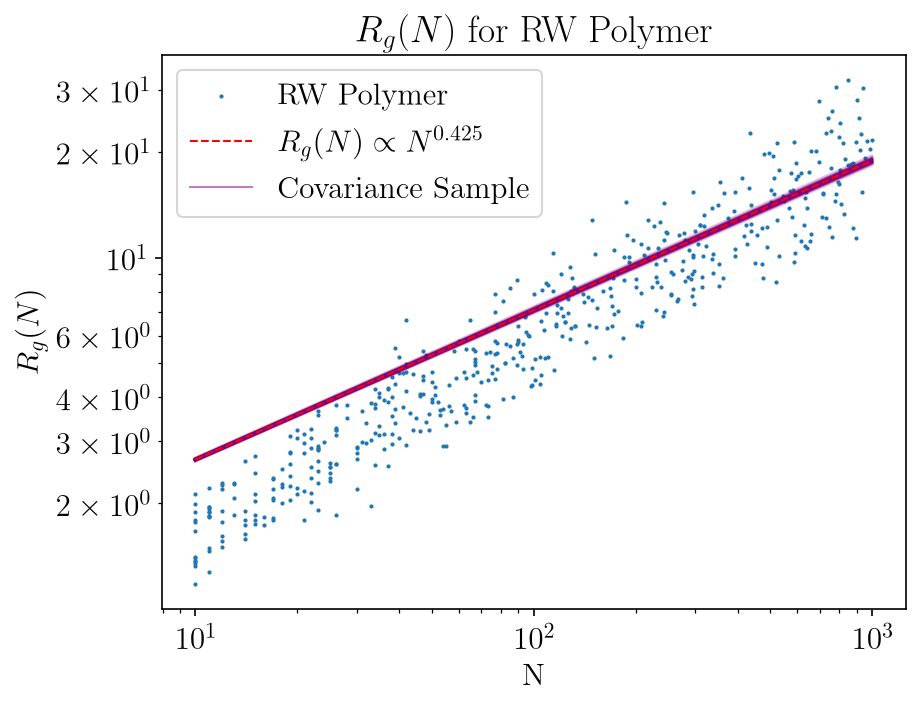

In [8]:
plt.figure()
data = plt.scatter(lengths, R_gs, s=1, label="RW Polymer")

from matplotlib.lines import Line2D
sample_handle = Line2D(
    [],                  # no x-data
    [],                  # no y-data
    color="purple",
    alpha=0.5,
    linewidth=1,
    label="Covariance Sample",
)

for i in range(100):
    rand_fit = Rg_func(lengths, np.random.multivariate_normal(Rg_N_popt, Rg_N_pcov))
    plt.plot(lengths, rand_fit, color="purple",alpha=.07)
fit, = plt.plot(lengths, Rg_func(lengths, *Rg_N_popt),color="red",linestyle="--",linewidth=1,label=rf"$R_g(N) \propto N^{{{Rg_N_popt[0]:.3f}}}$")
plt.ylabel(r"$R_g(N)$")
plt.xlabel("N")
plt.xscale("log")
plt.yscale("log")
plt.title(r"$R_g(N)$ for RW Polymer")
plt.legend(handles=[data, fit, sample_handle])
plt.savefig("RgVsN.png")

100%|██████████| 500/500 [04:04<00:00,  2.04it/s]  
/tmp/ipykernel_1732173/1102409254.py:26: RuntimeWarning: Mean of empty slice
  mean_Rg_n = np.nanmean(Rg_ns, axis=0)
/home/accts/ajy27/ohernlab/programs/constrained-polymer/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


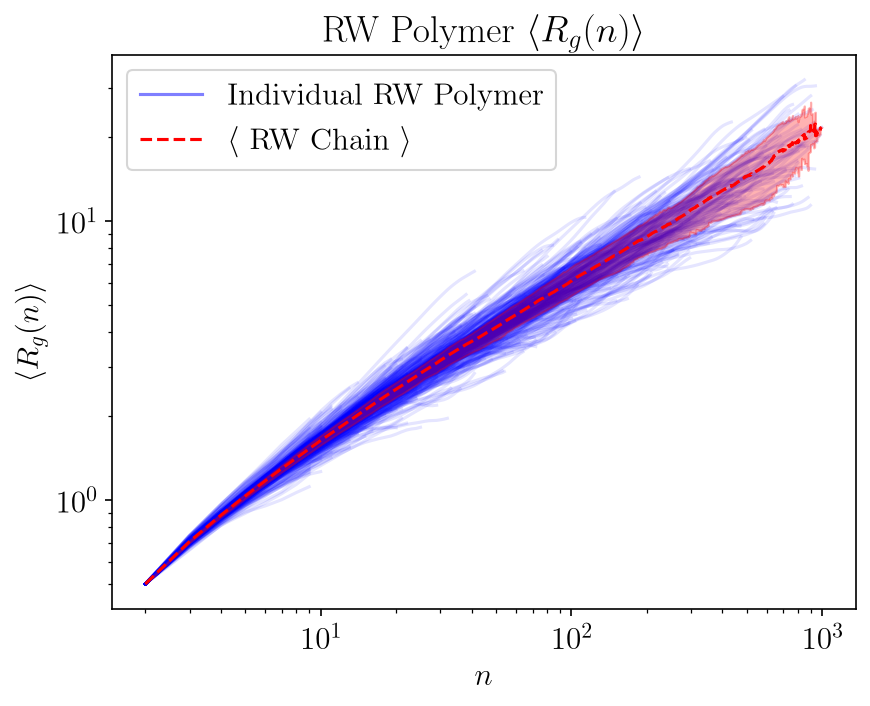

In [9]:
n_max = max(crw.n for crw in crw_list)

ns = np.arange(2, n_max+1)
Rg_ns = np.full((num_crw, len(ns)), np.nan)

plt.figure()
plt.title(r"RW Polymer $\langle R_g(n)\rangle$")
plt.xlabel(r"$n$")
plt.ylabel(r"$\langle R_g(n) \rangle$")
plt.xscale("log")
plt.yscale("log")
for crw_idx, crw in enumerate(tqdm(crw_list)):
    
    valid_ns = ns[ns < crw.n]
     
    for n_idx, n in enumerate(valid_ns):
        Rg_ns[crw_idx, n_idx]=crw.compute_rg_n(n)
    plt.plot(
             valid_ns, 
             Rg_ns[crw_idx, :len(valid_ns)], 
             c="b", 
             alpha=.1,
             zorder=1
        )

mean_Rg_n = np.nanmean(Rg_ns, axis=0)
Rg_lo, Rg_hi = np.nanpercentile(Rg_ns, [16, 84], axis=0)
sample_handle=Line2D(
    [],
    [],
    color="b",
    alpha=.5,
    label="Individual RW Polymer"
)
avg, = plt.plot(ns, mean_Rg_n, c="r", linestyle="--",label=r"$\langle$ RW Chain $\rangle$",zorder=3)
fill_between = plt.fill_between(ns, Rg_lo, Rg_hi, color="r", alpha=.3,zorder=2)
plt.legend(handles=[sample_handle, avg])
plt.savefig("Rg_n.png")
plt.show()

In [3]:
# Now when the polymers begin to fold what happens?
# First examine different central forces, and what they do to to final R_g(N) and the <R_g(n)> at different temperatures
# first output files to respective configs

# for i, rw in enumerate(tqdm(crw_list)):
#     rw.write_sim_config(f"../../input/rw_len_{rw.n}_no_{i}.txt")

# create a job array from all parameters
# parameters to test
import os
import numpy as np

out_dir = "./output/cf-mags-extended"
in_dir = "./input/"

input_files = os.listdir(in_dir)
output_files = os.listdir(out_dir)

input_files = list(filter(lambda filename: "crw" in filename, input_files))
output_files = list(filter(lambda filename: "Etot.txt" in filename, output_files))

print(input_files)
print(output_files)

['crw_128_0.txt', 'crw_256_0.txt', 'crw_512_0.txt', 'crw_1024_0.txt']
['crw_1024_0.cf_0.0010974987654930556.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0012045035402587824.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0013219411484660286.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0014508287784959402.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0015922827933410922.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.001747528400007683.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0019179102616724887.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.001.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.00210490414451202.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0023101297000831605.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0025353644939701114.dt_1e-2.temp_1e-6.damping_.1temp_rg_Etot.txt', 'crw_1024_0.cf_0.0027825

In [4]:
# For each file, there are multiple outputs, each beginning with that prefix, extract the final configurations and plot:
# 1. Final PE vs. N, group by cf-mag
# 2. Final Rg(n) vs. N, group by cf-mag
# 3. Final Rg(N) vs. N, grouped by cf-mag
from tqdm import tqdm
import re
import pandas as pd

columns = ["length", "cf-mag", "Rg_N", "E_tot"]
rows = []

pattern = re.compile(
    r"^crw_"
    r"(?P<length>\d+)_"
    r"(?P<id>\d+)"
    r"\.cf_(?P<cf>[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"
    r"\.dt_(?P<dt>[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"
    r"\.temp_(?P<temp>[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"
    r"\.damping_(?P<damping>[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)"
    r"temp_rg_Etot\.txt$"
)

for filename in tqdm(output_files):
    match = pattern.fullmatch(filename)
    if not match:
        continue

    with open(f"{out_dir}/{filename}", "r") as rg_file:
        last_line = rg_file.readlines()[-1].split()

    rg_N = float(last_line[1])
    E_tot = float(last_line[2])

    info = match.groupdict()

    rows.append(
        {
            "length": int(info["length"]),
            "cf-mag": float(info["cf"]),
            "Rg_N": rg_N,
            "E_tot": E_tot,
        }
    )

cf_frame = pd.DataFrame(rows, columns=columns)

print(cf_frame)

marker_list = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
color_list = ["#0072B2", "#E69F00", "#009E73", "#CC79A7",
              "#56B4E9", "#D55E00", "#F0E442", "#000000"]

100%|██████████| 400/400 [00:01<00:00, 219.33it/s]

     length    cf-mag     Rg_N        E_tot
0      1024  0.001097  4.55002     0.010493
1      1024  0.001205  4.53860     0.011531
2      1024  0.001322  4.52615     0.013387
3      1024  0.001451  4.52761     0.015672
4      1024  0.001592  4.51530     0.018793
..      ...       ...      ...          ...
395     512  6.280291  1.20201  1225.830000
396     512  6.892612  1.17102  1323.830000
397     512  7.564633  1.13969  1432.200000
398     512  8.302176  1.10973  1546.520000
399     512  9.111628  1.08073  1668.310000

[400 rows x 4 columns]


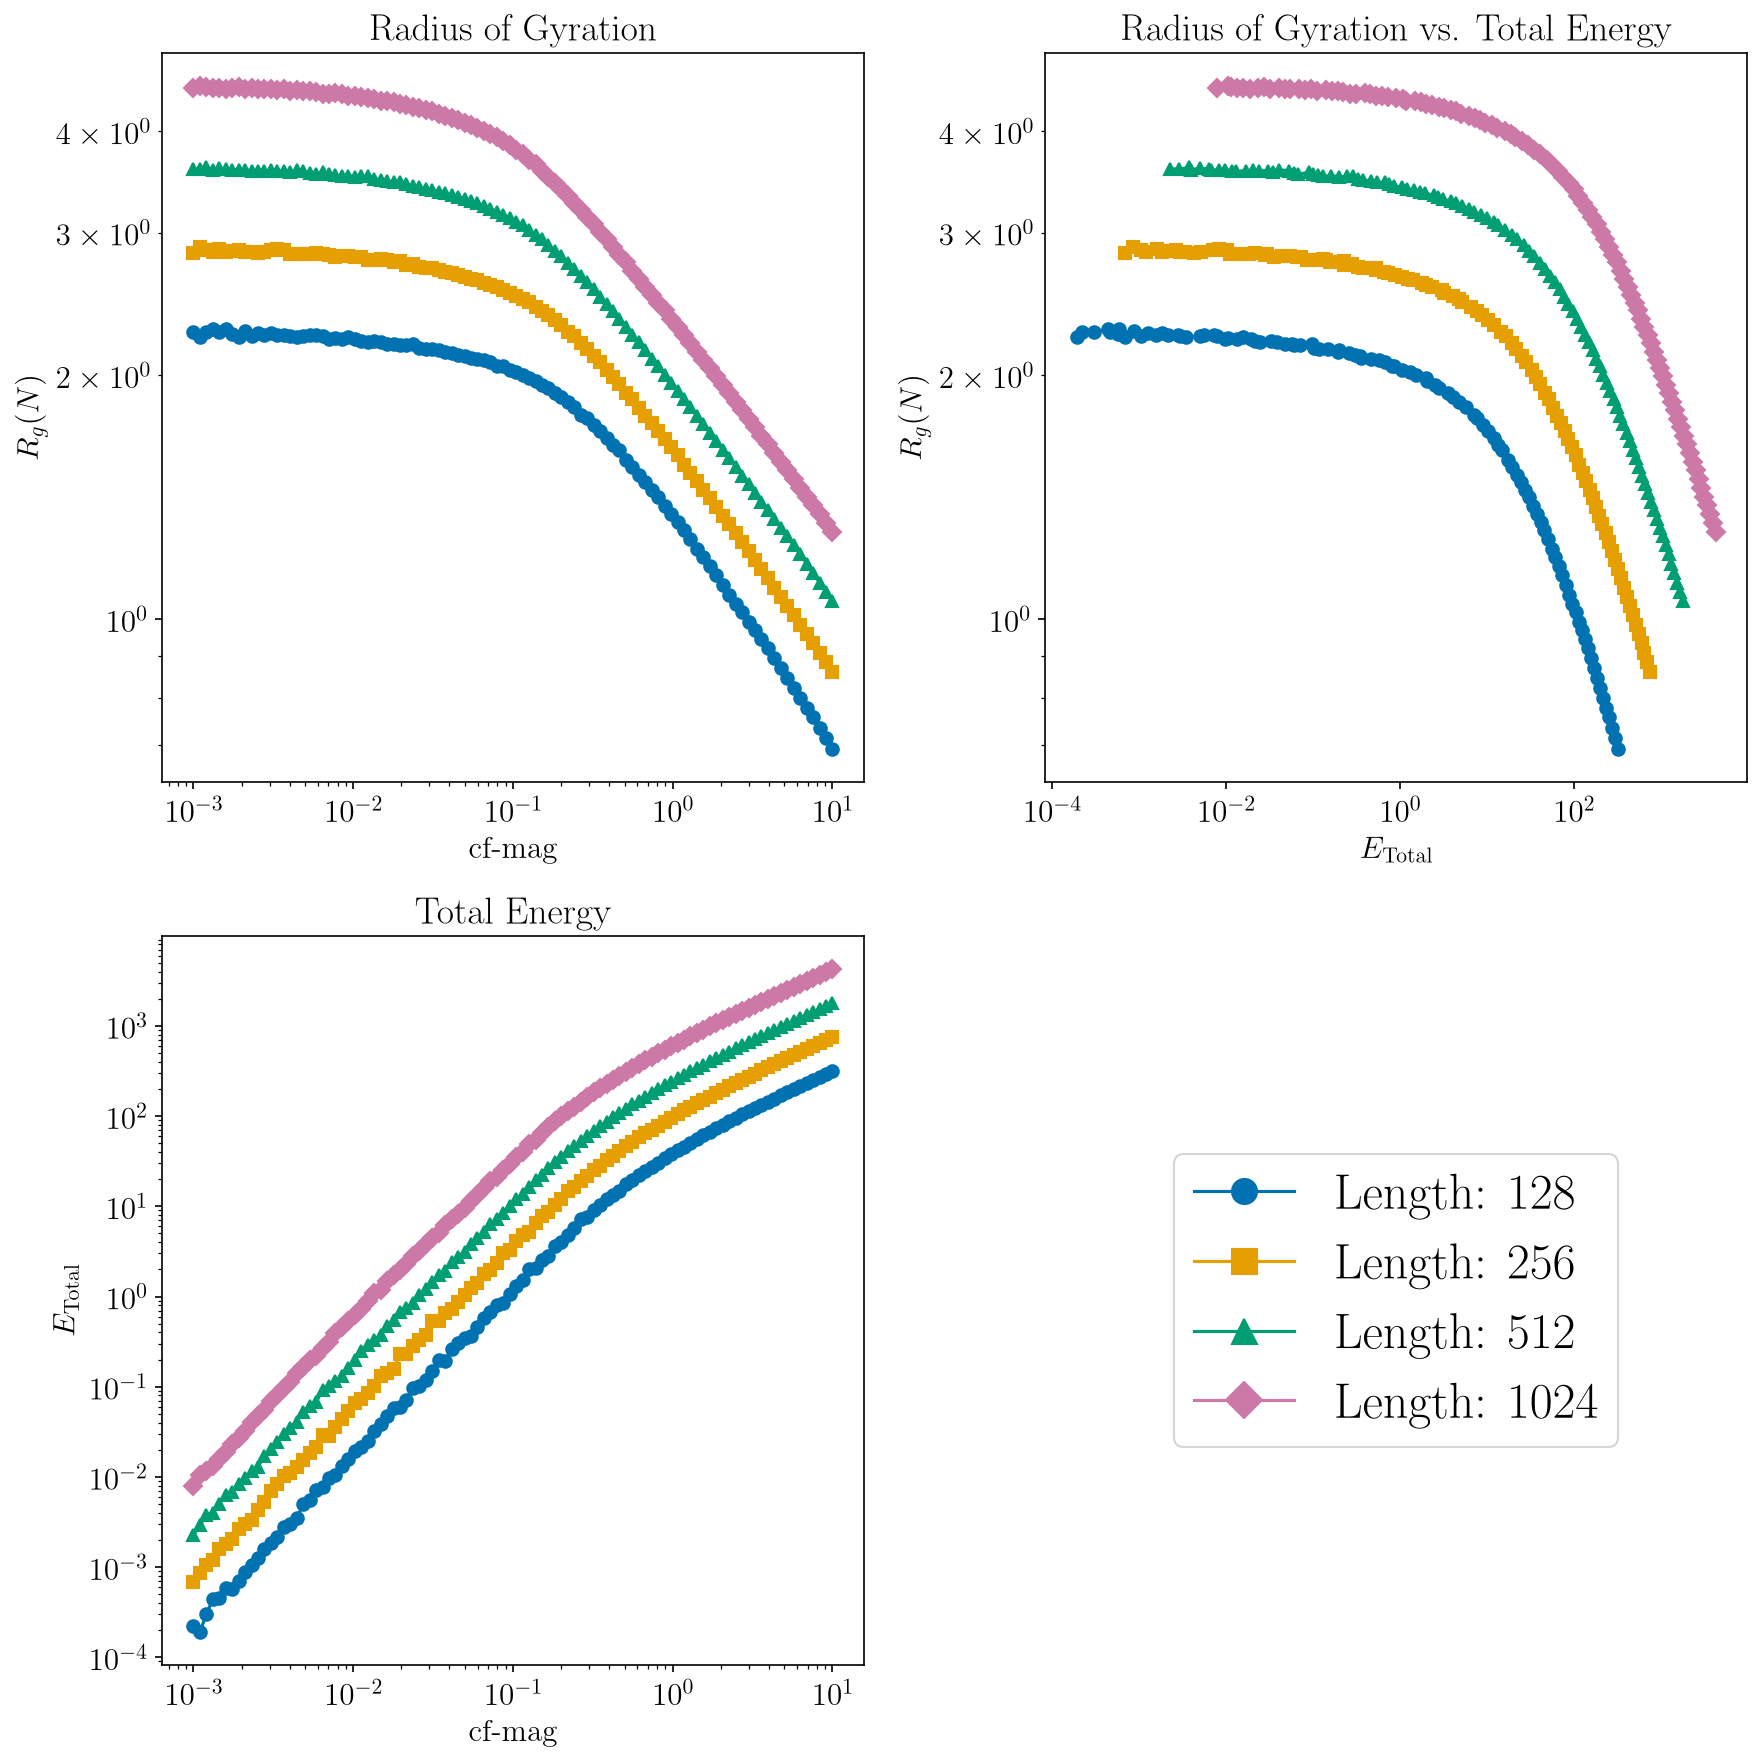

In [7]:
# Plot E_Tot against N, grouped by cf-mag

plot_logscale = True

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

labels = sorted(cf_frame["length"].unique())

styles = {
    label: {
        "marker": marker_list[i % len(marker_list)],
        "color": color_list[i % len(color_list)],
    }
    for i, label in enumerate(labels)
}

for length, group in cf_frame.groupby("length", sort=True):
    group = group.sort_values("cf-mag")

    cf_mags = group["cf-mag"]
    rg_N_values = group["Rg_N"]
    E_tot_values = group["E_tot"]

    ax[0, 0].plot(
        cf_mags,
        rg_N_values,
        label=f"Length: {length:g}",
        **styles[length],
    )
    ax[1, 0].plot(
        cf_mags,
        E_tot_values,
        label=f"Length: {length:g}",
        **styles[length],
    )
    ax[0, 1].plot(
        E_tot_values,
        rg_N_values,
        label=f"Length: {length:g}",
        **styles[length],
    )

ax[0, 0].set_title("Radius of Gyration")
ax[1, 0].set_title("Total Energy")
ax[0, 1].set_title("Radius of Gyration vs. Total Energy")

ax[0, 0].set_xlabel("cf-mag")
ax[1, 0].set_xlabel("cf-mag")
ax[0, 1].set_xlabel(r"$E_{\mathrm{Total}}$")

ax[0, 0].set_ylabel(r"$R_g(N)$")
ax[1, 0].set_ylabel(r"$E_{\mathrm{Total}}$")
ax[0, 1].set_ylabel(r"$R_g(N)$")

ax[1, 1].axis("off")
ax[1, 1].legend(
    *ax[0, 0].get_legend_handles_labels(),
    loc="center",
    fontsize=24,
    markerscale=2,
)

if plot_logscale:
    ax[0, 0].set_xscale("log")
    ax[1, 0].set_xscale("log")
    ax[0, 1].set_xscale("log")

    ax[0, 0].set_yscale("log")
    ax[1, 0].set_yscale("log")
    ax[0, 1].set_yscale("log")

plt.tight_layout()
plt.savefig(f"N-E-Rg-cf-mags-extended(log).png", dpi=300)
plt.show()



/tmp/ipykernel_475648/2260958850.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


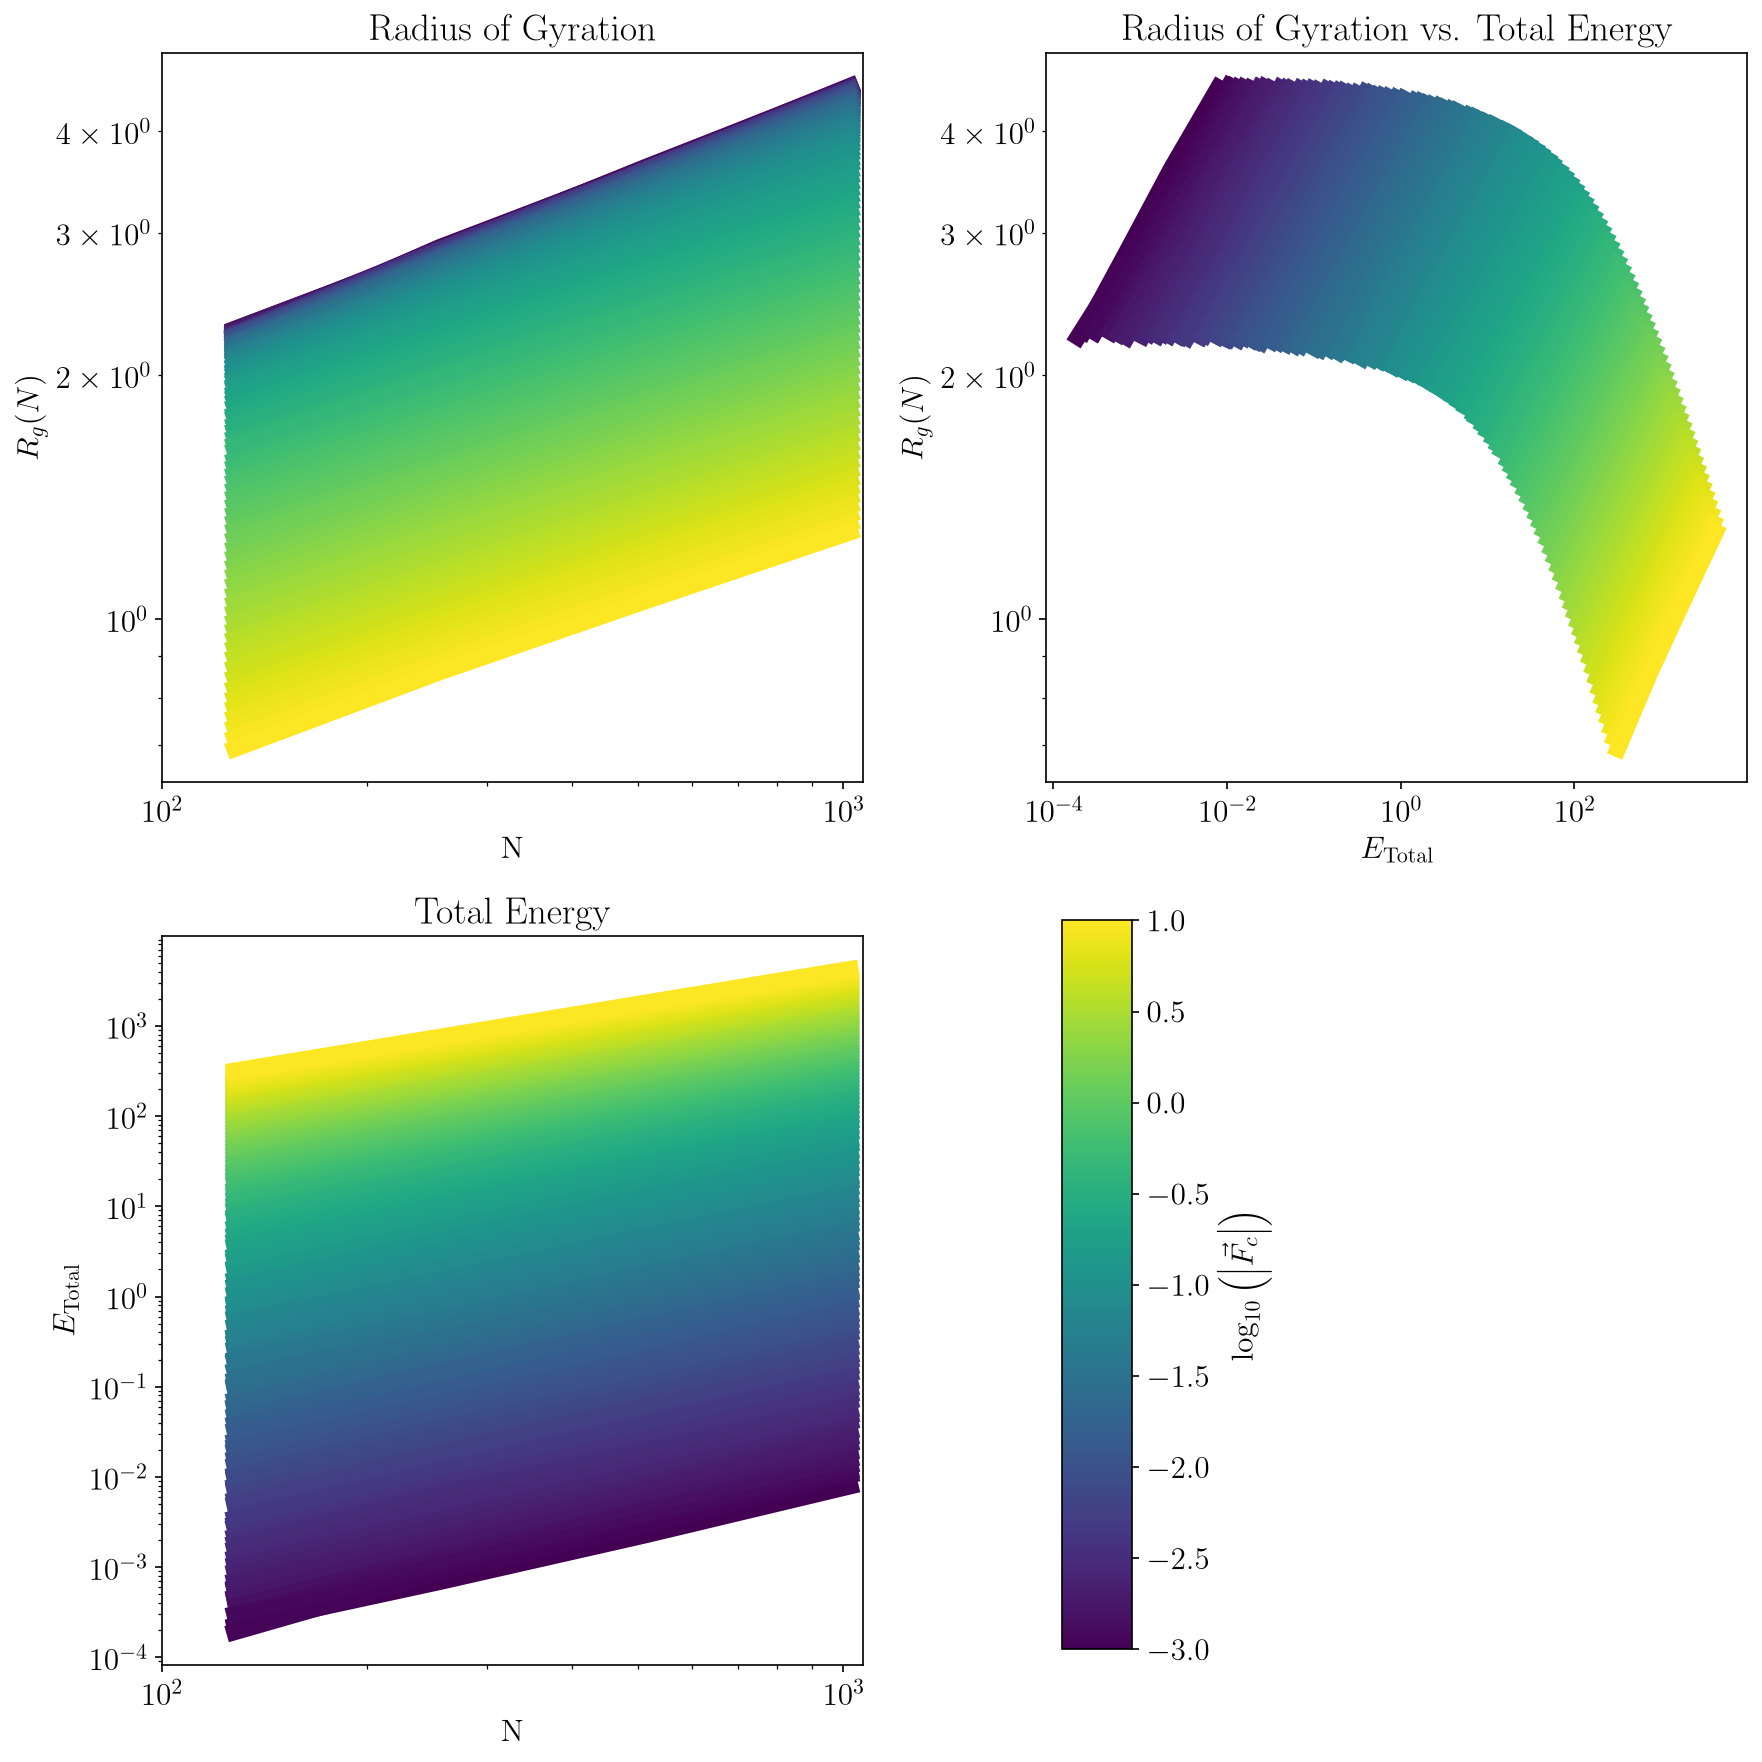

In [9]:

width=8
plot_logscale=True
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

cf_mags = cf_frame["cf-mag"].to_numpy()
norm = Normalize(vmin=np.log10(cf_mags.min()), vmax=np.log10(cf_mags.max()))
cmap = plt.colormaps["viridis"]

for cf_mag, group in cf_frame.groupby("cf-mag", sort=True):
    group = group.sort_values("length")

    lengths = group["length"]
    rg_N_values = group["Rg_N"]
    E_tot_values = group["E_tot"]

    color = cmap(norm(np.log10(cf_mag)))

    ax[0, 0].plot(
        lengths,
        rg_N_values,
        color=color,
        linewidth=width,
    )
    ax[1, 0].plot(
        lengths,
        E_tot_values,
        color=color,
        linewidth=width,
    )
    ax[0, 1].plot(
        E_tot_values,
        rg_N_values,
        color=color,
        linewidth=width,
    )

ax[0, 0].set_title("Radius of Gyration")
ax[1, 0].set_title("Total Energy")
ax[0, 1].set_title("Radius of Gyration vs. Total Energy")

ax[0, 0].set_xlabel("N")
ax[0, 0].set_xlim(left=1e2)
ax[1, 0].set_xlabel("N")
ax[1, 0].set_xlim(left=1e2)
ax[0, 1].set_xlabel(r"$E_{\mathrm{Total}}$")

ax[0, 0].set_ylabel(r"$R_g(N)$")
ax[1, 0].set_ylabel(r"$E_{\mathrm{Total}}$")
ax[0, 1].set_ylabel(r"$R_g(N)$")

# Color scale in the unused fourth subplot.
colorbar_map = ScalarMappable(norm=norm, cmap=cmap)
colorbar_map.set_array([])
ax[1, 1].set_axis_off()
fig.colorbar(
    colorbar_map,
    cax=inset_axes(ax[1, 1], width="10%",height="100%",loc="lower left"),
    label=r"$\text{log}_{10}\left(\left|\vec{F}_c\right|\right)$",
)

if plot_logscale:
    ax[0, 0].set_xscale("log")
    ax[1, 0].set_xscale("log")
    ax[0, 1].set_xscale("log")

    ax[0, 0].set_yscale("log")
    ax[0, 1].set_yscale("log")
    ax[1, 0].set_yscale("log")
    
plt.tight_layout()
plt.savefig("N-E-Rg-cf-mags-extended-contour(log).png", dpi=300)
plt.show()

In [ ]:
# For later

proteins_Rg_ns = []
for index,id in enumerate(pdb_ids):
    fetch_pdb.download_one(id, fmt="pdb", outdir="pdb_structures")
    import ipdb; ipdb.set_trace()
    struct = stats.load_pdb(f"pdb_structures/{id}.pdb")
    coords = np.array([r["CA"].get_vector().get_array()
                       for r in struct.get_residues() if "CA" in r])
    N = len(coords)
    ns = np.arange(1, N + 1)
    rg_vals = [stats.rg_n(coords, n) for n in ns]
    proteins_Rg_ns.append(rg_vals)
    if index > 10: break

  5D8VA: not found (404), skipping
> /tmp/ipykernel_1761418/3346182689.py(5)<module>()
      4     import ipdb; ipdb.set_trace()
----> 5     struct = stats.load_pdb(f"pdb_structures/{id}.pdb")
      6     coords = np.array([r["CA"].get_vector().get_array()

